# 03 — Modeling

**Day 3**

Load the feature-engineered data, build a preprocessing pipeline, train 3 models (Linear Regression, Random Forest, XGBoost), evaluate them on the test set, compare results, run cross-validation, and save the best model.

---
## Step 1: Setup & Imports

All the libraries needed for modeling, evaluation, and saving results.

In [1]:
# Standard data science
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# XGBoost
from xgboost import XGBRegressor

# Joblib for saving models
import joblib

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Project root for imports
import sys, os
sys.path.insert(0, os.path.dirname(os.path.dirname(os.path.abspath('.'))))

---
## Step 2: Load the Feature-Engineered Data

Load CleanData, then apply all feature engineering functions from src/features.py.

After this cell, `df` contains the fully prepared dataset: cleaned, imputed, with new derived features, ordinal-encoded categoricals, and one-hot-encoded nominals.

No duplicates
=== SalePrice — Basic Stats ===
count      2919.000000
mean     180052.854647
std       57381.565721
min       34900.000000
25%      154795.084126
50%      176734.841494
75%      191895.744157
max      755000.000000
Name: SalePrice, dtype: float64

Zero values: 0
Negative values: 0


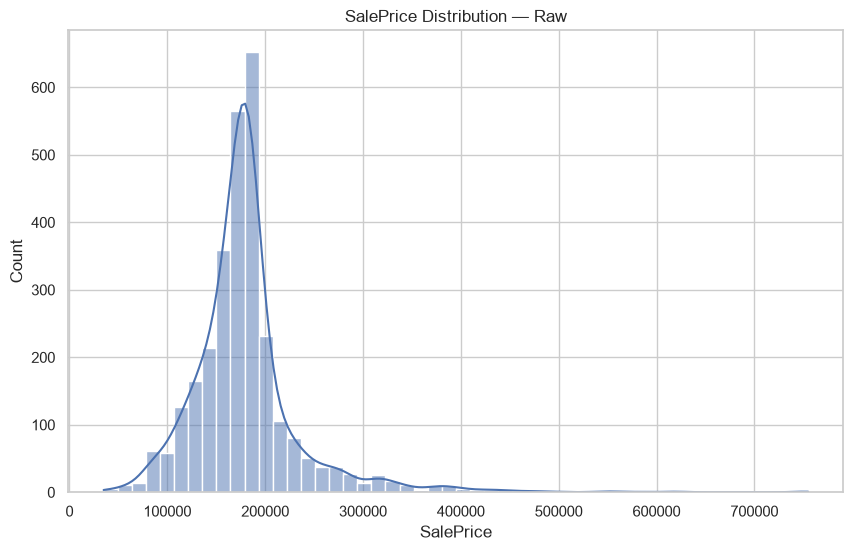


Skewness (raw SalePrice): 2.549


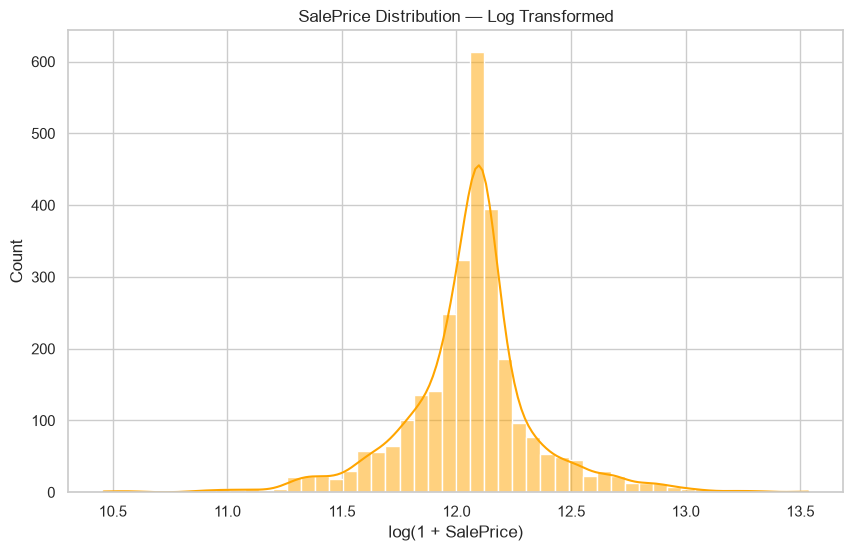

Skewness (log SalePrice): -0.150

→ Raw skewness: 2.549  →  Log skewness: -0.150
→ Log transform successfully normalized the distribution.
Shape after feature engineering: (2919, 186)
Total columns: 186
Missing values: 7
BsmtHalfBath    2
KitchenQual     1
GarageCars      1
GarageArea      1
TotalBath       2


In [14]:
# Load cleaned data
import sys
sys.path.insert(0, r'C:\Users\ycode\Documents\Ames-Housing-ML')

from src.preprocess import CleanData
from src.features import add_numeric_features, encode_ordinal_features, encode_nominal_features
from src.analysis import analyze_target

cleaner = CleanData()
dat = analyze_target(cleaner.clean_df)
df = dat

# Apply feature engineering
df = add_numeric_features(df)
df = encode_ordinal_features(df)

# One-hot encode nominal features
nominal_cols = [
    'MSZoning', 'Neighborhood', 'BldgType', 'HouseStyle',
    'RoofStyle', 'Foundation', 'CentralAir', 'PavedDrive',
    'SaleType', 'SaleCondition', 'Electrical', 'Functional',
    'Exterior1st', 'Exterior2nd', 'MasVnrType'
]
nominal_cols = [c for c in nominal_cols if c in df.columns]
df = encode_nominal_features(df, nominal_cols)

print(f'Shape after feature engineering: {df.shape}')
print(f'Total columns: {len(df.columns)}')

# Check for missing values
missing = df.isna().sum().sum()
print(f'Missing values: {missing}')
if missing > 0:
    print('WARNING: missing values found!')
    print(df.isna().sum()[df.isna().sum() > 0].to_string())

---
## Step 3: Prepare Features and Target

Separate the features (X) from the targets (y).

- **X** = all numeric columns except the two targets — this is what every model trains on
- **y_raw** = SalePrice (actual dollars) — used for Random Forest and XGBoost
- **y_log** = LogSalePrice — used for Linear Regression (the log transform fixes the skew)

After one-hot encoding, everything in the DataFrame is numeric, so X is simply:
all numeric columns minus SalePrice and LogSalePrice.

In [15]:
# X = all numeric columns except the two targets
exclude_cols = {'SalePrice', 'LogSalePrice'}
X = df.select_dtypes(include=[np.number]).drop(columns=exclude_cols, errors='ignore')

# Targets
y_raw = df['SalePrice']
y_log = df['LogSalePrice']

print(f'X shape: {X.shape}')
print(f'  features: {X.shape[1]}')
print(f'  samples:  {X.shape[0]}')
print(f'y_raw shape: {y_raw.shape}')
print(f'y_log shape: {y_log.shape}')

# Check for missing values in X
missing = X.isna().sum().sum()
print(f'Missing values in X: {missing}')
if missing > 0:
    print('Columns with missing values:')
    print(X.isna().sum()[X.isna().sum() > 0].to_string())

X shape: (2919, 174)
  features: 174
  samples:  2919
y_raw shape: (2919,)
y_log shape: (2919,)
Missing values in X: 7
Columns with missing values:
BsmtHalfBath    2
KitchenQual     1
GarageCars      1
GarageArea      1
TotalBath       2


---
## Step 4: Train/Test Split

Split the data 80/20. We use the same split for all 3 models so the comparison is fair.

We split both y_raw and y_log using the same indices.

In [16]:
# Split features and raw target
X_train, X_test, y_train_raw, y_test_raw = train_test_split(
    X, y_raw, test_size=0.2, random_state=42
)

# Split log target using the same indices
y_train_log = y_log.loc[y_train_raw.index]
y_test_log = y_log.loc[y_test_raw.index]

print(f'Training set:  {X_train.shape[0]} samples × {X_train.shape[1]} features')
print(f'Test set:      {X_test.shape[0]} samples × {X_test.shape[1]} features')

# Verify the split is aligned
assert X_train.index.equals(y_train_raw.index), 'X_train / y_train_raw index mismatch!'
assert X_test.index.equals(y_test_raw.index), 'X_test / y_test_raw index mismatch!'

Training set:  2335 samples × 174 features
Test set:      584 samples × 174 features


---
## Step 5: Build the Preprocessing Pipeline

The pipeline handles two things:
- **Imputation**: fills any NaN values with the median (in case some slipped through)
- **Scaling**: StandardScaler — required for Linear Regression, harmless for trees

This pipeline is the single source of truth for preprocessing. Every model uses it.

In [17]:
# Numeric transformer: impute + scale
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# ColumnTransformer applies the numeric transformer to all feature columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, list(X.columns)),
    ],
    remainder='drop'
)

print('Pipeline built. Steps:')
print(preprocessor)

# Test the pipeline on the training data
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

print(f'\nTransformed X_train: {X_train_transformed.shape}')
print(f'Transformed X_test:  {X_test_transformed.shape}')
print(f'NaNs in transformed train: {np.isnan(X_train_transformed).sum()}')

Pipeline built. Steps:
ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['Id', 'MSSubClass', 'LotFrontage', 'LotArea',
                                  'OverallQual', 'OverallCond', 'YearBuilt',
                                  'YearRemodAdd', 'MasVnrArea', 'ExterQual',
                                  'ExterCond', 'BsmtQual', 'BsmtCond',
                                  'BsmtFinSF1', 'BsmtUnfSF', 'TotalBsmtSF',
                                  'HeatingQC', '1stFlrSF', '2ndFlrSF',
                                  'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath',
                                  'FullBath', 'HalfBath', 'BedroomAbvGr',
                                  'KitchenQual', 'TotRmsAbvGrd', 'Fireplaces',
                          

---
## Step 6: Train Model 1 — Linear Regression

Linear Regression uses **LogSalePrice** as the target.

Why? The raw SalePrice is skewed (long tail of expensive houses). Linear Regression assumes the target is normally distributed — the log transform fixes this.

After prediction, we convert back to dollars with `np.expm1()`.

In [21]:
# Build the full pipeline: preprocessor + Linear Regression
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Train on LogSalePrice
print('Training Linear Regression on LogSalePrice...')
lr_pipeline.fit(X_train, y_train_log)

# Predict on test set (output is in log space)
y_pred_lr_log = lr_pipeline.predict(X_test)

# Convert predictions back to dollars
y_pred_lr = np.expm1(y_pred_lr_log)

# Evaluate on raw SalePrice
lr_mae = mean_absolute_error(y_test_raw, y_pred_lr)
lr_rmse = np.sqrt(mean_squared_error(y_test_raw, y_pred_lr))
lr_r2 = r2_score(y_test_raw, y_pred_lr)

print('\n=== Linear Regression — Test Set Results ===')
print(f'MAE:  ${lr_mae:>10,.0f}')
print(f'RMSE: ${lr_rmse:>10,.0f}')
print(f'R²:   {lr_r2:>10.4f}')

# Store for comparison
lr_results = {'Model': 'Linear Regression', 'MAE': lr_mae, 'RMSE': lr_rmse, 'R²': lr_r2}

# Show first 10 predictions vs actual
print('\n=== First 10 Predictions vs Actual ===')
pred_df = pd.DataFrame({
    'Actual ($)': y_test_raw.values[:10],
    'Predicted ($)': y_pred_lr[:10],
    'Error ($)': y_pred_lr[:10] - y_test_raw.values[:10],
})
print(pred_df.to_string())

Training Linear Regression on LogSalePrice...

=== Linear Regression — Test Set Results ===
MAE:  $    31,020
RMSE: $    45,334
R²:       0.4488

=== First 10 Predictions vs Actual ===
      Actual ($)  Predicted ($)     Error ($)
0  180096.931198  158785.273580 -21311.657618
1  192686.931748  204508.062333  11821.130585
2  158151.985049  147184.198918 -10967.786131
3  187500.000000  221115.781230  33615.781230
4  172023.677782  195789.516000  23765.838218
5  311872.000000  230064.543201 -81807.456799
6  154034.917446  115135.981881 -38898.935564
7  260000.000000  171801.969374 -88198.030626
8  185998.255166  141621.973515 -44376.281651
9  181613.035129  182134.917391    521.882261


---
## Step 7: Train Model 2 — Random Forest

Random Forest uses **raw SalePrice** as the target.

Trees don't need the target to be normally distributed, so we use the raw dollars. They're also not affected by feature scaling — but we still run data through the pipeline for consistency.

In [22]:
# Build the full pipeline: preprocessor + Random Forest
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(
        n_estimators=200,
        max_depth=15,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ))
])

# Train on raw SalePrice
print('Training Random Forest on SalePrice...')
rf_pipeline.fit(X_train, y_train_raw)

# Predict
y_pred_rf = rf_pipeline.predict(X_test)

# Evaluate
rf_mae = mean_absolute_error(y_test_raw, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test_raw, y_pred_rf))
rf_r2 = r2_score(y_test_raw, y_pred_rf)

print('\n=== Random Forest — Test Set Results ===')
print(f'MAE:  ${rf_mae:>10,.0f}')
print(f'RMSE: ${rf_rmse:>10,.0f}')
print(f'R²:   {rf_r2:>10.4f}')

# Store for comparison
rf_results = {'Model': 'Random Forest', 'MAE': rf_mae, 'RMSE': rf_rmse, 'R²': rf_r2}

# Feature importance
rf_model = rf_pipeline.named_steps['regressor']
rf_importances = pd.Series(rf_model.feature_importances_, index=X.columns)
print('\n=== Random Forest — Top 15 Feature Importances ===')
print(rf_importances.sort_values(ascending=False).head(15).to_string())

Training Random Forest on SalePrice...

=== Random Forest — Test Set Results ===
MAE:  $     9,951
RMSE: $    20,078
R²:       0.8919

=== Random Forest — Top 15 Feature Importances ===
TotalSF         0.415379
Id              0.225764
OverallQual     0.106340
GarageCars      0.019238
LotArea         0.019231
BedroomAbvGr    0.019146
2ndFlrSF        0.017343
BsmtFinSF1      0.016288
BsmtQual        0.012548
GrLivArea       0.009707
TotalBath       0.009413
KitchenQual     0.008378
BsmtUnfSF       0.008301
LotFrontage     0.008040
GarageArea      0.007021


---
## Step 8: Train Model 3 — XGBoost

XGBoost uses **raw SalePrice** as the target.

Same setup as Random Forest — pipeline + XGBRegressor.

In [23]:
# Build the full pipeline: preprocessor + XGBoost
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', XGBRegressor(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        verbosity=0
    ))
])

# Train on raw SalePrice
print('Training XGBoost on SalePrice...')
xgb_pipeline.fit(X_train, y_train_raw)

# Predict
y_pred_xgb = xgb_pipeline.predict(X_test)

# Evaluate
xgb_mae = mean_absolute_error(y_test_raw, y_pred_xgb)
xgb_rmse = np.sqrt(mean_squared_error(y_test_raw, y_pred_xgb))
xgb_r2 = r2_score(y_test_raw, y_pred_xgb)

print('\n=== XGBoost — Test Set Results ===')
print(f'MAE:  ${xgb_mae:>10,.0f}')
print(f'RMSE: ${xgb_rmse:>10,.0f}')
print(f'R²:   {xgb_r2:>10.4f}')

# Store for comparison
xgb_results = {'Model': 'XGBoost', 'MAE': xgb_mae, 'RMSE': xgb_rmse, 'R²': xgb_r2}

# Feature importance
xgb_model = xgb_pipeline.named_steps['regressor']
xgb_importances = pd.Series(xgb_model.feature_importances_, index=X.columns)
print('\n=== XGBoost — Top 15 Feature Importances ===')
print(xgb_importances.sort_values(ascending=False).head(15).to_string())

Training XGBoost on SalePrice...

=== XGBoost — Test Set Results ===
MAE:  $    10,409
RMSE: $    19,432
R²:       0.8987

=== XGBoost — Top 15 Feature Importances ===
TotalSF                 0.131265
GarageCars              0.081997
OverallQual             0.063589
CentralAir_Y            0.053053
KitchenQual             0.030561
BsmtQual                0.027351
Exterior2nd_ImStucc     0.026562
Exterior2nd_Wd Shng     0.025541
HasFireplace            0.024758
GrLivArea               0.024313
Neighborhood_NoRidge    0.021532
IsNew                   0.020284
SaleType_New            0.019652
Id                      0.018488
ExterQual               0.017712


---
## Step 9: Compare All Models

Side-by-side comparison of the 3 models on the test set.

=== Model Comparison — Test Set ===
                            MAE          RMSE        R²
Model                                                  
Linear Regression  31019.678039  45333.864072  0.448783
Random Forest       9951.150436  20077.552164  0.891882
XGBoost            10408.781546  19432.111688  0.898722

=== Best Model: XGBoost ===
MAE:  $    10,409
RMSE: $    19,432
R²:       0.8987


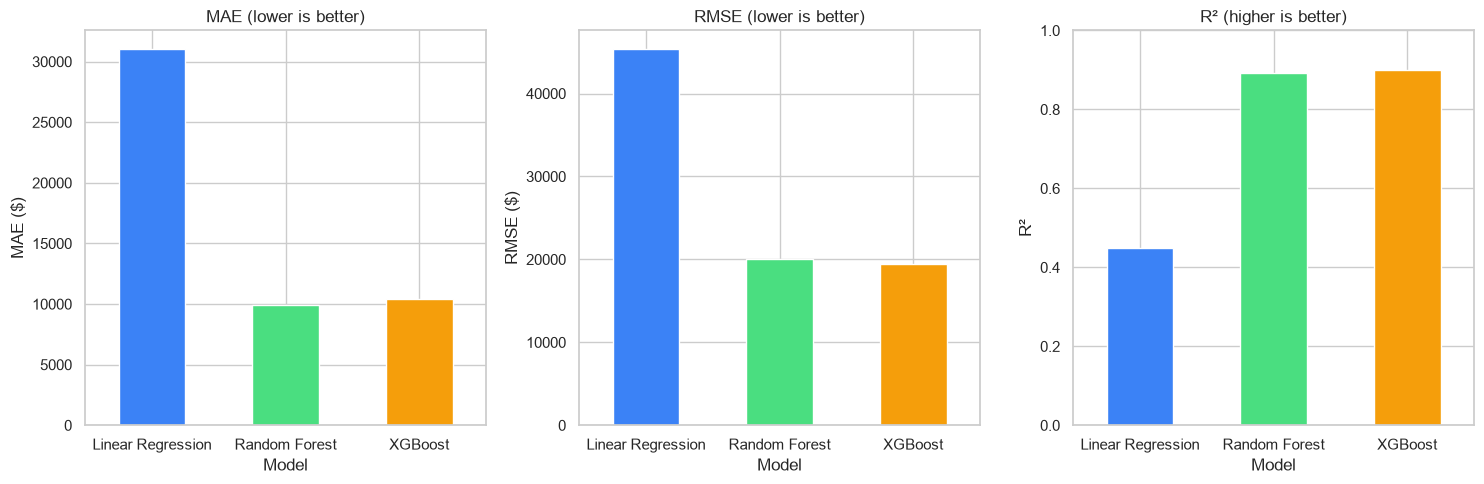

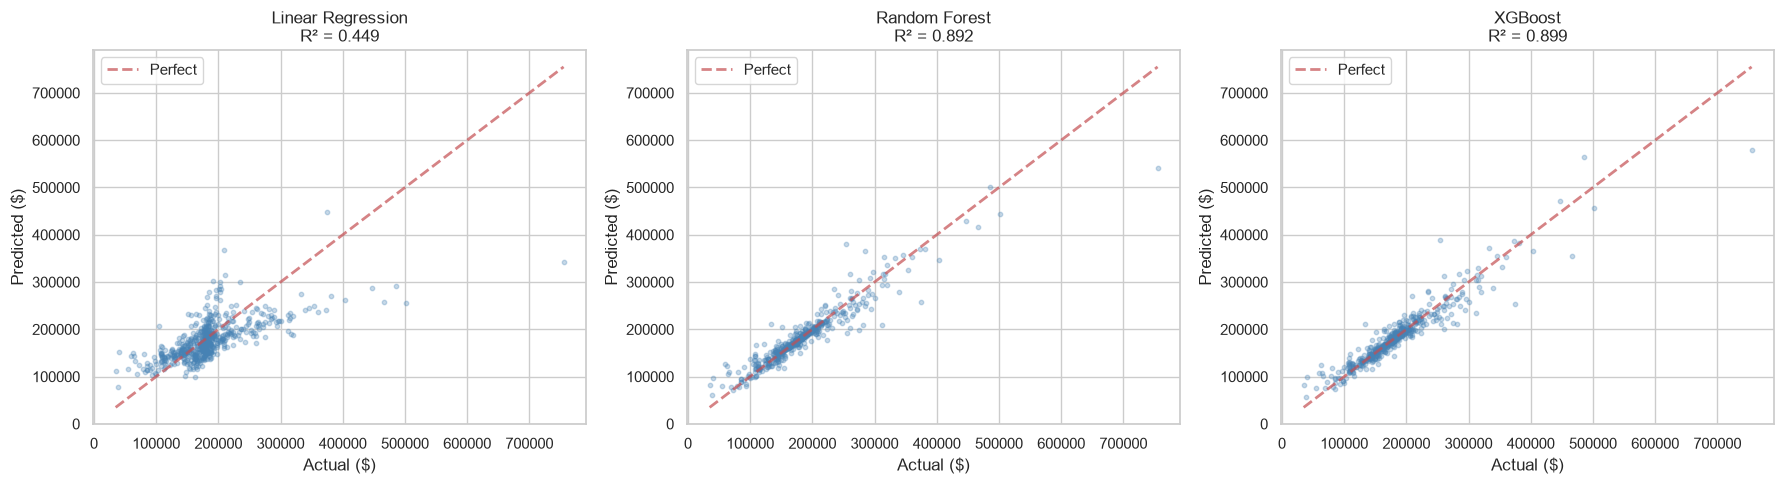

In [24]:
# Build comparison table
comparison = pd.DataFrame([lr_results, rf_results, xgb_results])
comparison = comparison.set_index('Model')[['MAE', 'RMSE', 'R²']]

print('=== Model Comparison — Test Set ===')
print(comparison.to_string())

# Find the best model by R²
best_model_name = comparison['R²'].idxmax()
best_mae = comparison.loc[best_model_name, 'MAE']
best_rmse = comparison.loc[best_model_name, 'RMSE']
best_r2 = comparison.loc[best_model_name, 'R²']

print(f'\n=== Best Model: {best_model_name} ===')
print(f'MAE:  ${best_mae:>10,.0f}')
print(f'RMSE: ${best_rmse:>10,.0f}')
print(f'R²:   {best_r2:>10.4f}')

# Visual comparison: bar charts
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

colors = ['#3b82f6', '#4ade80', '#f59e0b']
comparison['MAE'].plot(kind='bar', ax=axes[0], color=colors)
axes[0].set_title('MAE (lower is better)')
axes[0].set_ylabel('MAE ($)')
axes[0].tick_params(axis='x', rotation=0)

comparison['RMSE'].plot(kind='bar', ax=axes[1], color=colors)
axes[1].set_title('RMSE (lower is better)')
axes[1].set_ylabel('RMSE ($)')
axes[1].tick_params(axis='x', rotation=0)

comparison['R²'].plot(kind='bar', ax=axes[2], color=colors)
axes[2].set_title('R² (higher is better)')
axes[2].set_ylabel('R²')
axes[2].set_ylim(0, 1)
axes[2].tick_params(axis='x', rotation=0)

for ax in axes:
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

# Actual vs predicted scatter plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models_preds = [
    ('Linear Regression', y_pred_lr),
    ('Random Forest', y_pred_rf),
    ('XGBoost', y_pred_xgb),
]

for ax, (name, preds) in zip(axes, models_preds):
    ax.scatter(y_test_raw, preds, alpha=0.3, s=10, color='steelblue')
    ax.plot([y_test_raw.min(), y_test_raw.max()],
            [y_test_raw.min(), y_test_raw.max()],
            'r--', alpha=0.7, linewidth=2, label='Perfect')
    ax.set_title(f'{name}\nR² = {comparison.loc[name, "R²"]:.3f}')
    ax.set_xlabel('Actual ($)')
    ax.set_ylabel('Predicted ($)')
    ax.legend()

plt.tight_layout()
plt.show()

---
## Step 10: Cross-Validation (Linear Regression)

Quick 5-fold cross-validation on the training set to check if the Linear Regression result is stable across different data splits.

This helps catch overfitting — if the test R² is much better than the CV R², the model may have gotten lucky with the train/test split.

In [25]:
# Cross-validation for Linear Regression (on LogSalePrice)
print('=== Cross-Validation — Linear Regression ===')
print('5-fold CV on training set (LogSalePrice target)\n')

lr_pipeline_cv = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# R² scores
cv_r2_scores = cross_val_score(lr_pipeline_cv, X_train, y_train_log,
                                cv=kf, scoring='r2')

# MAE scores (negative because sklearn returns negative for error metrics)
cv_mae_scores = -cross_val_score(lr_pipeline_cv, X_train, y_train_log,
                                  cv=kf, scoring='neg_mean_absolute_error')

print(f'CV R² scores per fold: {cv_r2_scores}')
print(f'CV MAE scores per fold (log): {cv_mae_scores}')

print(f'\nMean CV R²: {cv_r2_scores.mean():.4f} ± {cv_r2_scores.std():.4f}')
print(f'Mean CV MAE (log): {cv_mae_scores.mean():.4f} ± {cv_mae_scores.std():.4f}')

# Compare with test set result
print(f'\n--- Comparison with Test Set ---')
print(f'Test set R²:  {lr_r2:.4f}')
print(f'CV mean R²:  {cv_r2_scores.mean():.4f}')
diff = abs(lr_r2 - cv_r2_scores.mean())
print(f'Difference:  {diff:.4f}')
if diff < 0.02:
    print('-> Test result is consistent with CV. Model is stable.')
else:
    print('-> Some discrepancy. The test result may be optimistic.')

# Also run CV on raw SalePrice for reference
print('\n--- CV on raw SalePrice (for reference) ---')
lr_pipeline_raw = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])
cv_r2_raw = cross_val_score(lr_pipeline_raw, X_train, y_train_raw,
                             cv=kf, scoring='r2')
print(f'Mean CV R² (raw target): {cv_r2_raw.mean():.4f} ± {cv_r2_raw.std():.4f}')

=== Cross-Validation — Linear Regression ===
5-fold CV on training set (LogSalePrice target)

CV R² scores per fold: [0.44090297 0.34998413 0.47251315 0.4278245  0.41568339]
CV MAE scores per fold (log): [0.16063638 0.15734259 0.16010727 0.1708147  0.15707295]

Mean CV R²: 0.4214 ± 0.0404
Mean CV MAE (log): 0.1612 ± 0.0050

--- Comparison with Test Set ---
Test set R²:  0.4488
CV mean R²:  0.4214
Difference:  0.0274
-> Some discrepancy. The test result may be optimistic.

--- CV on raw SalePrice (for reference) ---
Mean CV R² (raw target): 0.3684 ± 0.0660


---
## Step 11: Save the Best Model

Save the best-performing model (full pipeline, so it includes preprocessing) to disk.

The saved pipeline can be loaded later and used to predict on new data directly.

In [26]:
# Pick the best pipeline
if best_model_name == 'Linear Regression':
    best_pipeline = lr_pipeline
elif best_model_name == 'Random Forest':
    best_pipeline = rf_pipeline
else:
    best_pipeline = xgb_pipeline

# Create models directory
os.makedirs('models', exist_ok=True)

# Save the full pipeline (preprocessing + model)
pipeline_path = 'models/best_pipeline.pkl'
joblib.dump(best_pipeline, pipeline_path)
print(f'Saved pipeline → {pipeline_path}')

# Save just the model object (without preprocessing)
model_path = 'models/best_model.pkl'
joblib.dump(best_pipeline.named_steps['regressor'], model_path)
print(f'Saved model → {model_path}')

# Save the feature names (needed to prepare new data for prediction)
feature_names_path = 'models/feature_names.json'
import json
with open(feature_names_path, 'w') as f:
    json.dump(list(X.columns), f, indent=2)
print(f'Saved feature names → {feature_names_path}')

# Save target info (which target was used, performance metrics)
target_info = {
    'model_name': best_model_name,
    'target': 'LogSalePrice' if best_model_name == 'Linear Regression' else 'SalePrice',
    'test_mae': float(best_mae),
    'test_rmse': float(best_rmse),
    'test_r2': float(best_r2),
}
target_info_path = 'models/target_info.json'
with open(target_info_path, 'w') as f:
    json.dump(target_info, f, indent=2)
print(f'Saved target info → {target_info_path}')

print(f'\nBest model: {best_model_name}')
print(f'Test MAE:  ${best_mae:,.0f}')
print(f'Test RMSE: ${best_rmse:,.0f}')
print(f'Test R²:   {best_r2:.4f}')

Saved pipeline → models/best_pipeline.pkl
Saved model → models/best_model.pkl
Saved feature names → models/feature_names.json
Saved target info → models/target_info.json

Best model: XGBoost
Test MAE:  $10,409
Test RMSE: $19,432
Test R²:   0.8987


---
## Step 12: Error Analysis

Look at where the best model makes the biggest errors.

This helps identify systematic issues — e.g., does the model underestimate expensive houses? Does it struggle with certain neighborhoods?

In [27]:
# Pick predictions from the best model
if best_model_name == 'Linear Regression':
    best_preds = y_pred_lr
elif best_model_name == 'Random Forest':
    best_preds = y_pred_rf
else:
    best_preds = y_pred_xgb

# Compute errors
errors = best_preds - y_test_raw.values
abs_errors = np.abs(errors)
pct_errors = abs_errors / y_test_raw.values * 100

print(f'=== Error Analysis — Best Model: {best_model_name} ===')
print(f'Mean Absolute Error:     ${abs_errors.mean():>10,.0f}')
print(f'Median Absolute Error:   ${np.median(abs_errors):>10,.0f}')
print(f'Max Absolute Error:      ${abs_errors.max():>10,.0f}')
print(f'Mean Percentage Error:   {pct_errors.mean():>10.1f}%')
print(f'Median Percentage Error: {np.median(pct_errors):>10.1f}%')

# Build error DataFrame
error_df = pd.DataFrame({
    'Actual': y_test_raw.values,
    'Predicted': best_preds,
    'Error': errors,
    'AbsError': abs_errors,
    'PctError': pct_errors,
})

# Bin by actual price range
bins = [0, 100000, 150000, 200000, 250000, 300000, 500000, 1000000]
labels = ['<100K', '100-150K', '150-200K', '200-250K', '250-300K', '300-500K', '500K+']
error_df['PriceBin'] = pd.cut(error_df['Actual'], bins=bins, labels=labels)

print('\n=== Error by Price Range ===')
error_by_bin = error_df.groupby('PriceBin').agg(
    Count=('Actual', 'count'),
    MAE=('AbsError', 'mean'),
    MedianPctError=('PctError', 'median'),
).round(1)
print(error_by_bin.to_string())

# Worst 10 predictions
print('\n=== 10 Worst Predictions (largest absolute error) ===')
worst = error_df.nlargest(10, 'AbsError')[['Actual', 'Predicted', 'Error', 'PctError']]
print(worst.to_string())

# Best 10 predictions
print('\n=== 10 Best Predictions (lowest absolute error) ===')
best_preds_df = error_df.nsmallest(10, 'AbsError')[['Actual', 'Predicted', 'Error', 'PctError']]
print(best_preds_df.to_string())

=== Error Analysis — Best Model: XGBoost ===
Mean Absolute Error:     $    10,409
Median Absolute Error:   $     4,952
Max Absolute Error:      $   175,388
Mean Percentage Error:          6.3%
Median Percentage Error:        2.8%

=== Error by Price Range ===
          Count       MAE  MedianPctError
PriceBin                                 
<100K        26   21350.6            18.2
100-150K    105    8930.2             4.4
150-200K    323    5310.0             1.3
200-250K     72   12671.6             4.7
250-300K     35   28216.4             7.9
300-500K     21   35705.5             6.4
500K+         2  110533.0            16.2

=== 10 Worst Predictions (largest absolute error) ===
            Actual      Predicted          Error   PctError
532  755000.000000  579612.125000 -175387.875000  23.230182
296  253293.000000  388732.375000  135439.375000  53.471424
494  375000.000000  253455.593750 -121544.406250  32.411842
198  466500.000000  354634.187500 -111865.812500  23.979810
463  48

---
## Step 13: Next Steps — Day 4 Preview

**Day 4 — Cross-Validation, Tuning, and Error Analysis**

1. **K-Fold Cross-Validation** for all 3 models (not just Linear Regression)
2. **GridSearchCV** on at least 1 model to tune hyperparameters:
   - Random Forest: `n_estimators`, `max_depth`, `min_samples_split`
   - XGBoost: `n_estimators`, `max_depth`, `learning_rate`
3. **Feature importance** comparison across models
4. **Error analysis** — which features correlate with large errors?
5. **Final model selection** — which model to use for the app?

**Reminder for the Streamlit app (Day 5):**
- The app loads the saved model and predicts directly — no retraining
- New input data must be preprocessed the same way (same feature names, same encoding)
- The app uses the same `feature_names.json` to know which columns to expect